# Inflation Trends in the United States (2004 – Present)

## Consumer Price Index (CPI) vs. Core CPI Year-over-Year

### Description

This notebook provides a technical visualization of U.S. inflationary trends over the past two decades. Utilizing data retrieved from the Federal Reserve Economic Data (FRED) system, it evaluates and contrasts two primary macroeconomic metrics:

- **Headline CPI (All Urban Consumers | FRED: CPIAUCSL):** Reflects the price changes of a representative basket of goods and services, capturing aggregate consumer price movements.
- **Core CPI (All Items Less Food and Energy | FRED: CPILFESL):** Isolates the structural, long-term inflation trend by stripping away historically volatile food and energy commodity components.

The analysis is conducted using year-over-year (YoY) percentage changes, allowing for a smoothed structural overview of consumer purchasing power and underlying macroeconomic momentum.

---

## Objectives

- **Long-Term Trend Analysis:** Evaluate structural inflation patterns from 2004 through the present day.
- **Metric Variance:** Compare the sensitivity and decoupling behavior of headline inflation versus core inflation during commodity shocks.
- **Macroeconomic Chronology:** Identify and map specific historical periods of structural inflation acceleration (reflation/hyper-demand) and deceleration (disinflation/deflation).
- **Policy Contextualization:** Provide a data-driven timeline mapping inflation fluctuations to Federal Reserve monetary cycles and global economic events.

---

## Data Source

- **Federal Reserve Economic Data (FRED)**  
  - `CPIAUCSL`: Consumer Price Index for All Urban Consumers: All Items  
  - `CPILFESL`: Consumer Price Index for All Urban Consumers: All Items Less Food and Energy  
  - `DPCCRV1A225NBEA`: Personal Consumption Expenditures (PCE) Excluding Food and Energy (chain-type price index)  
  - `PCETRIM12M159SFRBDAL`: Trimmed Mean PCE Inflation Rate

---

## CPI Inflation (2004–Present): Historical Chronology

### Major Macroeconomic Events Impacting Trends:
- **2008 Great Recession & Housing Market Collapse:** Sharp contraction in aggregate demand leading to historical disinflationary/deflationary pressures.
- **2020 COVID-19 Pandemic:** Initial deflationary shock followed by massive global supply-chain disruptions and unprecedented fiscal stimulus.
- **2021–2023 Post-Pandemic Inflationary Surge:** A historic peak in global inflation driven by surging consumer demand, structural labor shortages, and energy market imbalances.
- **2022–2024 Fed Monetary Tightening Cycle:** Aggressive interest rate hikes enacted by the Federal Reserve to cool demand and anchor long-term inflation expectations back to the 2.0% target.
- **Global Geopolitical Friction (2022–Present):** Supply chain friction and commodity shocks amplified by the Russia-Ukraine war and escalating conflicts in the Middle East.

## Pre-Processing

### Install System Dependencies

In [1]:
!pip install pandas-datareader
# Note: Uncomment below if necessary to ugrade installer
# !pip3 install --upgrade pip


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


### Import Python Libraries

In [2]:
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.transforms as transforms
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

### Define Global Functions 

In [3]:
def add_event_lines(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=10,
                     fontweight='bold')
            
def add_event_lines_small(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=5,
                     fontweight='bold')
            
def add_event_lines_large(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=15,
                     fontweight='bold')

### Standard Unit Initial Timeframe

In [4]:
start = datetime(2005, 1, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(years=1)

## CPI Inflation: 20-Year Historical

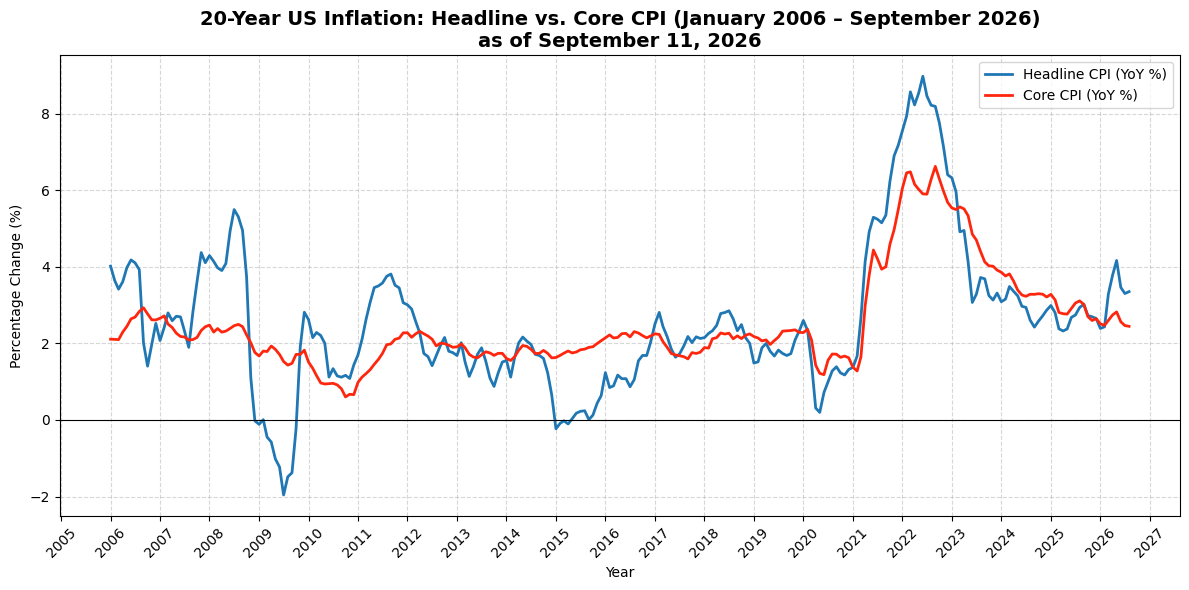

In [5]:
cpi_series = {
'CPIAUCSL': 'CPI for All Urban Consumers: All Items', 
'CPILFESL': 'CPI for All Urban Consumers: All Items Less Food and Energy'
}

df = web.DataReader(list(cpi_series.keys()), 'fred', start, end)
df.rename(columns=cpi_series, inplace=True)
df = df.ffill()

df_yoy = df.pct_change(periods=12) * 100

plt.figure(figsize=(12, 6))

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items'],
        label='Headline CPI (YoY %)', 
        color='#1f77b4', 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items Less Food and Energy'],
        label='Core CPI (YoY %)', 
        color="#ff260e", 
        linewidth=2)

y = plt.ylim()[1]*0.85

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# plot formatting
plt.title(f'20-Year US Inflation: Headline vs. Core CPI ({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

## 10-Year Historical Index
- 2008 Finanical Housing Crisis
- COVID-19 Pandemic
- Start of Iran War

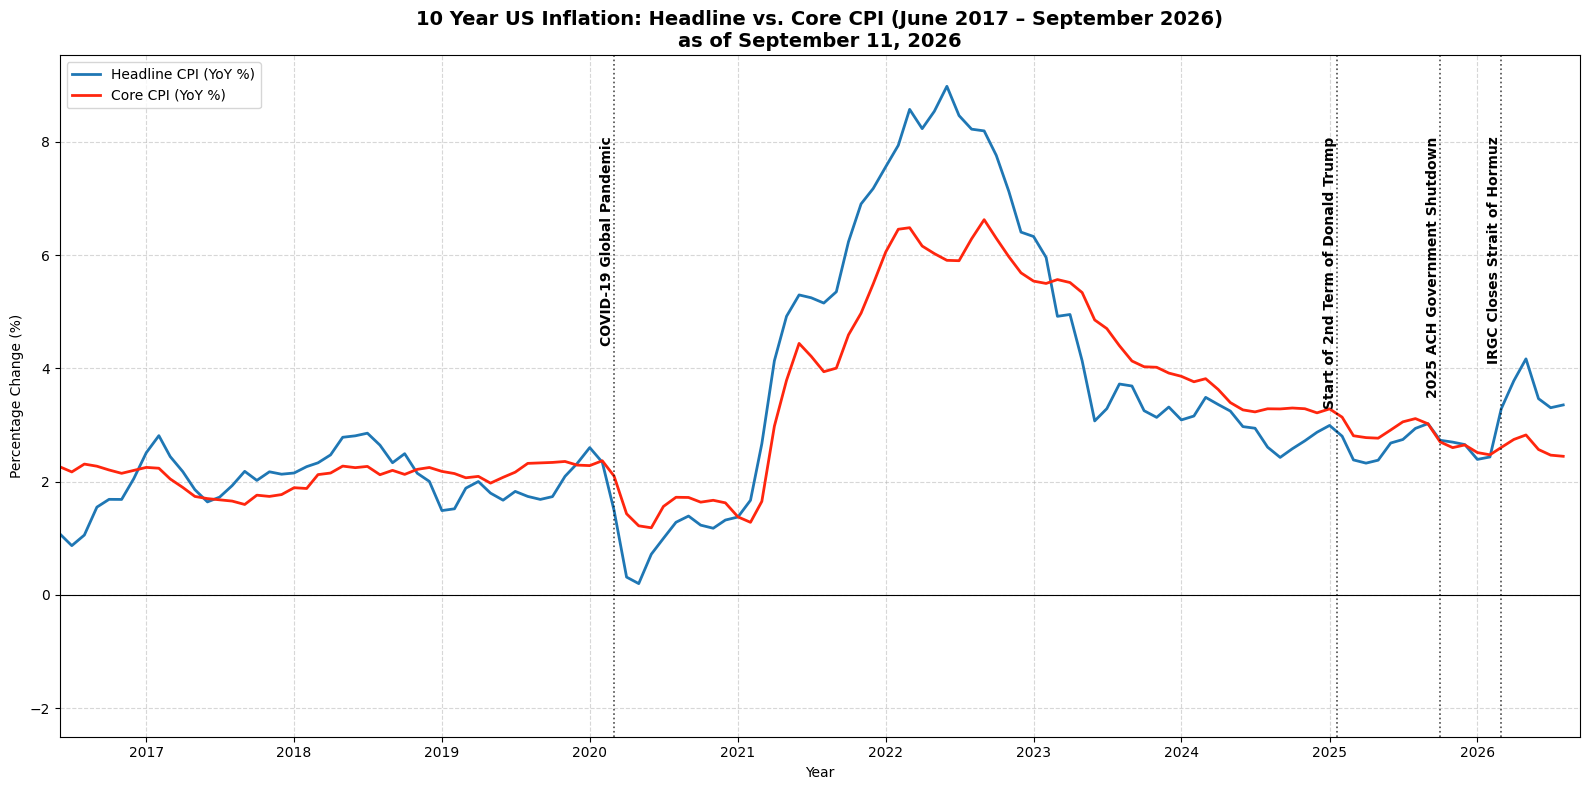

In [12]:
# timeframe
start = datetime(2016, 6, 1)

plot_start = start + relativedelta(years=1)

plt.figure(figsize=(16, 8))

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items'],
        label='Headline CPI (YoY %)', 
        color='#1f77b4', 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items Less Food and Energy'],
        label='Core CPI (YoY %)', 
        color="#ff260e", 
        linewidth=2)

y = plt.ylim()[1]*0.85

events = {
'2007-12-01': '2008 U.S. Housing Crisis Recession',
'2020-03-01': 'COVID-19 Global Pandemic',
'2025-01-20': 'Start of 2nd Term of Donald Trump',
'2025-10-01': '2025 ACH Government Shutdown',
'2026-02-28': 'IRGC Closes Strait of Hormuz'
}

# plot formatting
plt.title(f'10 Year US Inflation: Headline vs. Core CPI ({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlim(start,end)
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
add_event_lines(events , df, y)
plt.legend()
plt.tight_layout()

plt.show()

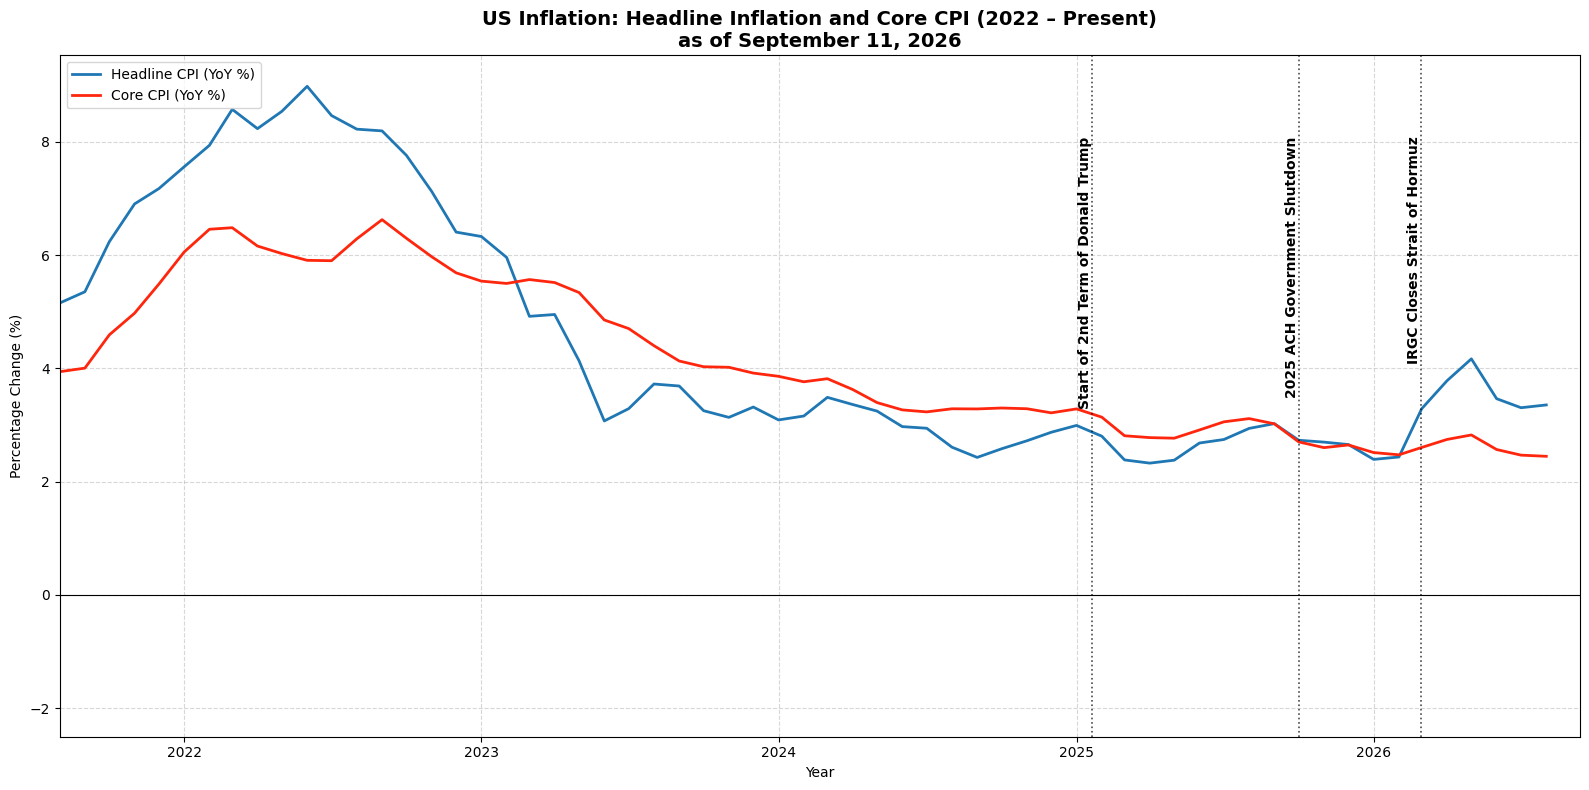

In [7]:
# timeframe
start = datetime(2021, 8, 1)

plot_start = start + relativedelta(years=1)

plt.figure(figsize=(16, 8))

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items'],
        label='Headline CPI (YoY %)', 
        color='#1f77b4', 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items Less Food and Energy'],
        label='Core CPI (YoY %)', 
        color="#ff260e", 
        linewidth=2)

y = plt.ylim()[1]*0.85

events = {
'2025-01-20': 'Start of 2nd Term of Donald Trump',
'2025-10-01': '2025 ACH Government Shutdown',
'2026-02-28': 'IRGC Closes Strait of Hormuz'
}

# plot formatting
plt.title(f'US Inflation: Headline Inflation and Core CPI ({plot_start.strftime("%Y")} – Present)\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlim(start,end)
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
add_event_lines(events , df, y)
plt.legend()
plt.tight_layout()

plt.show()

## CPI Inflation (July 2020-Present)
### Key Events
- Presidential Inauguration of Donald J. Trump's as the 47th President of the United States of America.
- Effective start of President Trump's global tariffs policy.
- U.S. Congressional 43-day shutdown.
- Iran closed the Straight of Hormuz.

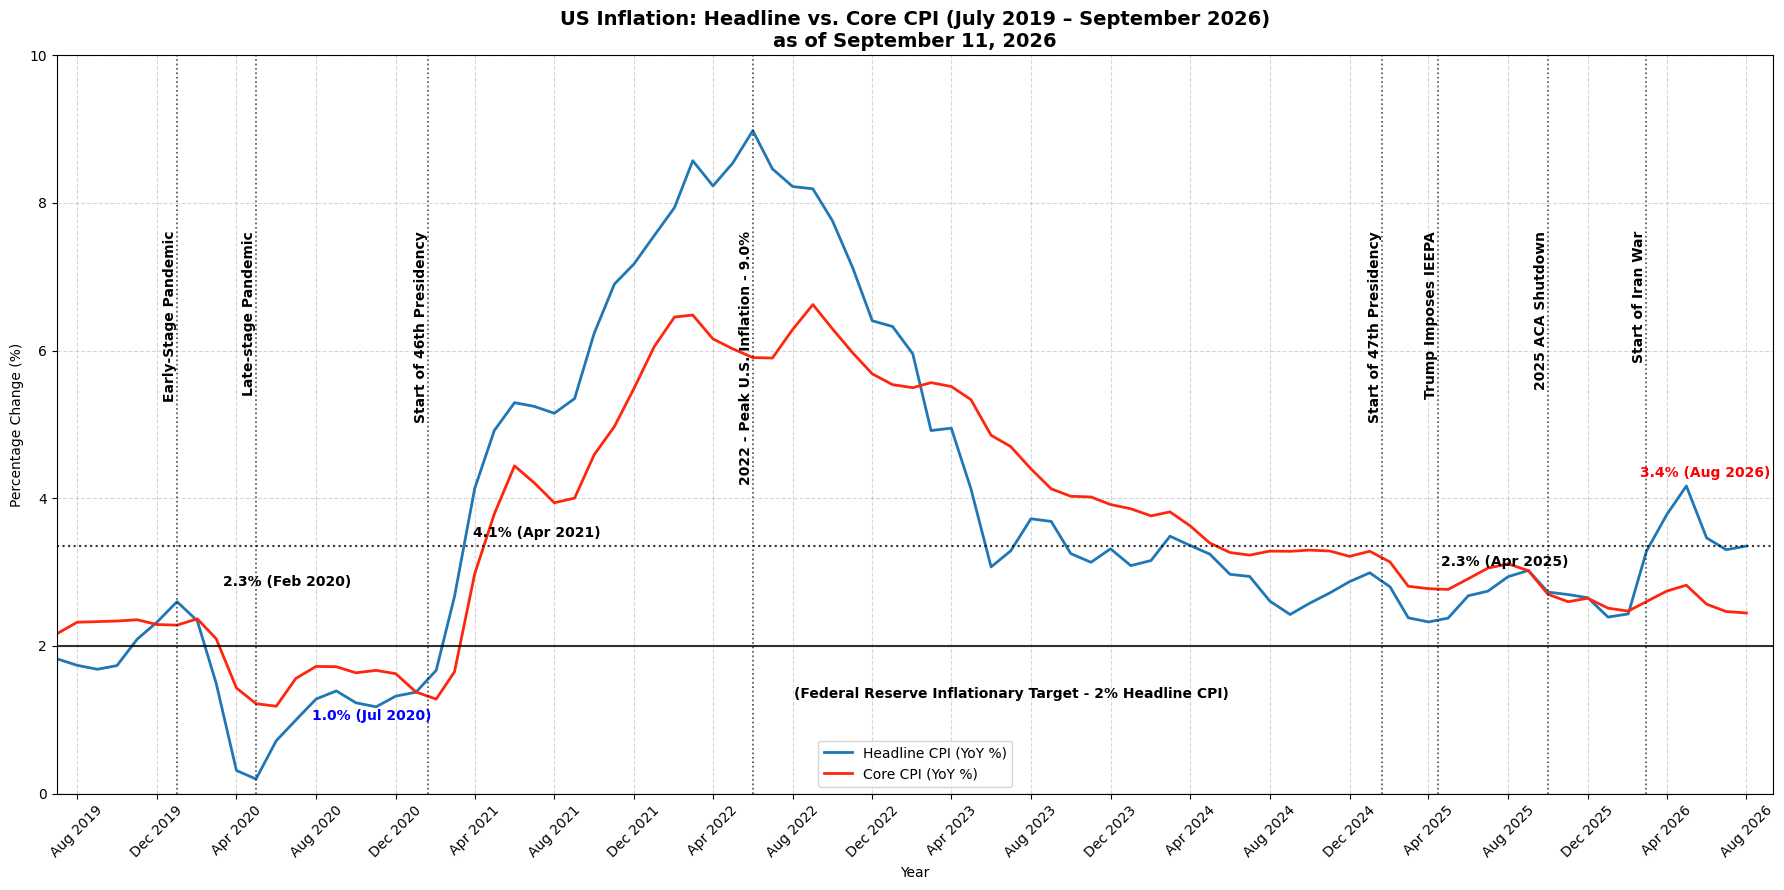

In [8]:
events = {
'2025-01-20': 'Start of 47th Presidency',
'2025-4-15': 'Trump Imposes IEEPA',
'2025-10-01': '2025 ACA Shutdown',
'2026-02-28': 'Start of Iran War',
'2020-01-01': 'Early-Stage Pandemic',
'2020-05-01': 'Late-stage Pandemic',
'2021-01-20': 'Start of 46th Presidency',
'2022-06-01': '2022 - Peak U.S. Inflation - 9.0%'
}

# Present values
r_date = df_yoy['CPI for All Urban Consumers: All Items'].dropna().index[-1]
r_val = df_yoy['CPI for All Urban Consumers: All Items'].dropna().iloc[-1]

# Pandemic Start
p_date = df_yoy['CPI for All Urban Consumers: All Items'].dropna().index[-74]
p_val = df_yoy['CPI for All Urban Consumers: All Items'].dropna().iloc[-74]

# Pre-Pandemic Peak
c_date = df_yoy['CPI for All Urban Consumers: All Items'].dropna().index[-79]
c_val = df_yoy['CPI for All Urban Consumers: All Items'].dropna().iloc[-79]

# 46th President
x1_date = df_yoy['CPI for All Urban Consumers: All Items'].dropna().index[-65]
x1_val = df_yoy['CPI for All Urban Consumers: All Items'].dropna().iloc[-65]

# 47th President
x2_date = df_yoy['CPI for All Urban Consumers: All Items'].dropna().index[-17]
x2_val = df_yoy['CPI for All Urban Consumers: All Items'].dropna().iloc[-17]

# timeframe
start = datetime(2019, 7, 1)
plot_start = start + relativedelta(years=1)

# Plot
plt.figure(figsize=(18, 9))

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items'],
        label='Headline CPI (YoY %)', 
        color='#1f77b4', 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items Less Food and Energy'],
        label='Core CPI (YoY %)', 
        color="#ff260e", 
        linewidth=2)

y = plt.ylim()[1]*0.8

# Formatting
plt.title(f'US Inflation: Headline vs. Core CPI ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xlim(start, end)
plt.ylim(0,10)
ax = plt.gca() # Get current axes object

# Mnnthl-by-month axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
plt.xticks(rotation=45)

add_event_lines(events, df, y)
plt.annotate(f"{r_val:.1f}% ({r_date.strftime('%b %Y')})", 
             (r_date, r_val), 
             textcoords = "offset points", 
             xytext = (-30,50), 
             ha = 'center', 
             weight = 'bold', 
             color = 'red')
plt.annotate(f"{p_val:.1f}% ({p_date.strftime('%b %Y')})", 
             (p_date, p_val), 
             textcoords = "offset points", 
             xytext = (55,0), 
             ha = 'center', 
             weight = 'bold', 
             color = 'blue')
plt.annotate(f"{c_val:.1f}% ({c_date.strftime('%b %Y')})", 
             (c_date, c_val), 
             textcoords = "offset points", 
             xytext = (65,25), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.annotate(f"{x1_val:.1f}% ({x1_date.strftime('%b %Y')})", 
             (x1_date, x1_val), 
             textcoords = "offset points", 
             xytext = (45,-35), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.annotate(f"{x2_val:.1f}% ({x2_date.strftime('%b %Y')})", 
             (x2_date, x2_val), 
             textcoords = "offset points", 
             xytext = (55,40), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.annotate(f"(Federal Reserve Inflationary Target - 2% Headline CPI)", 
             (x2_date, x2_val), 
             textcoords = "offset points", 
             xytext = (-300,-55), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.axhline(y=r_val, 
            color="#000000", 
            linestyle=':', 
            linewidth=1.5, 
            alpha=0.8)
plt.axhline(y=2, 
            color="#000000", 
            linestyle='-', 
            linewidth=1.5, 
            alpha=0.8)


plt.legend()
plt.tight_layout()

plt.show()

## Personal Consumption Expenditures (PCE)

### Real Personal Consumption Expenditures Per Capita: 10-Year Historical 

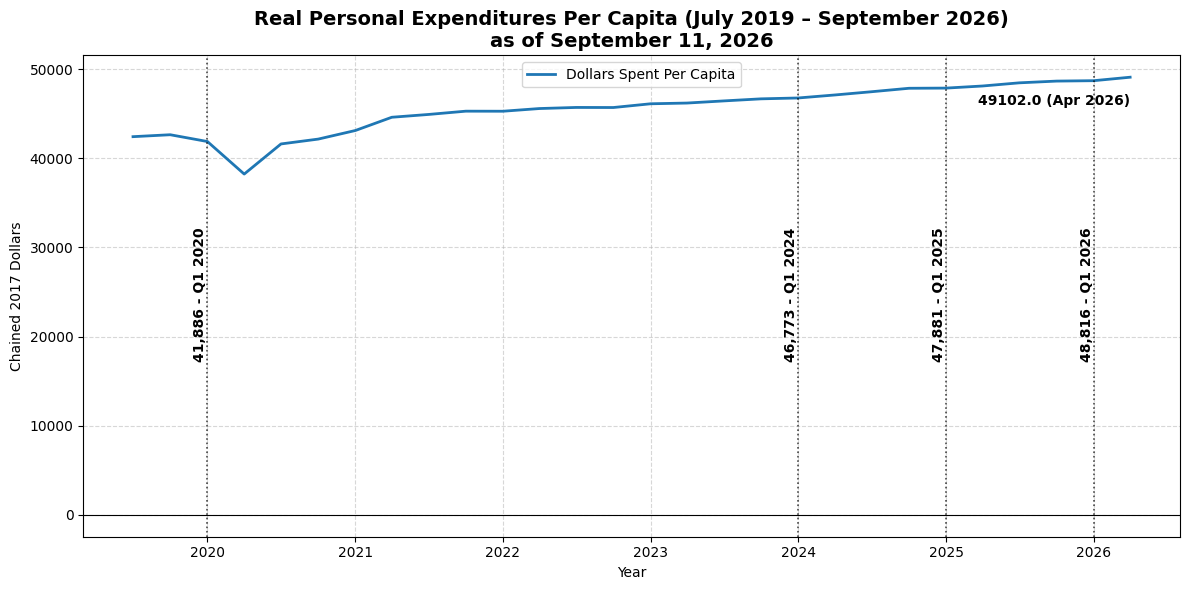

In [9]:
# source: FRED
df = web.DataReader('A794RX0Q048SBEA', 'fred', start, end)

# values
r_date = df['A794RX0Q048SBEA'].dropna().index[-1]
r_val = df['A794RX0Q048SBEA'].dropna().iloc[-1]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['A794RX0Q048SBEA'], 
         label="Dollars Spent Per Capita", 
         color='#1f77b4', 
         linewidth=2)

y = plt.ylim()[1]*0.65



# Q1 2016-2026
fyq_s1 = {
    '2016-01-1': '39,667 - Q1 2016',
    '2020-01-1': '41,886 - Q1 2020',
    '2024-01-1': '46,773 - Q1 2024',
    '2025-01-1': '47,881 - Q1 2025',
    '2026-01-1': '48,816 - Q1 2026'
}

plt.title(f'Real Personal Expenditures Per Capita ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Chained 2017 Dollars')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
add_event_lines(fyq_s1, df, y)
plt.annotate(f"{r_val:.1f} ({r_date.strftime('%b %Y')})", 
             (r_date, r_val), 
             textcoords = "offset points", 
             xytext = (-55,-20), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.legend()
plt.tight_layout()

plt.show()

### Consumer Price Index for All Urban Consumers: 5-Year Historical

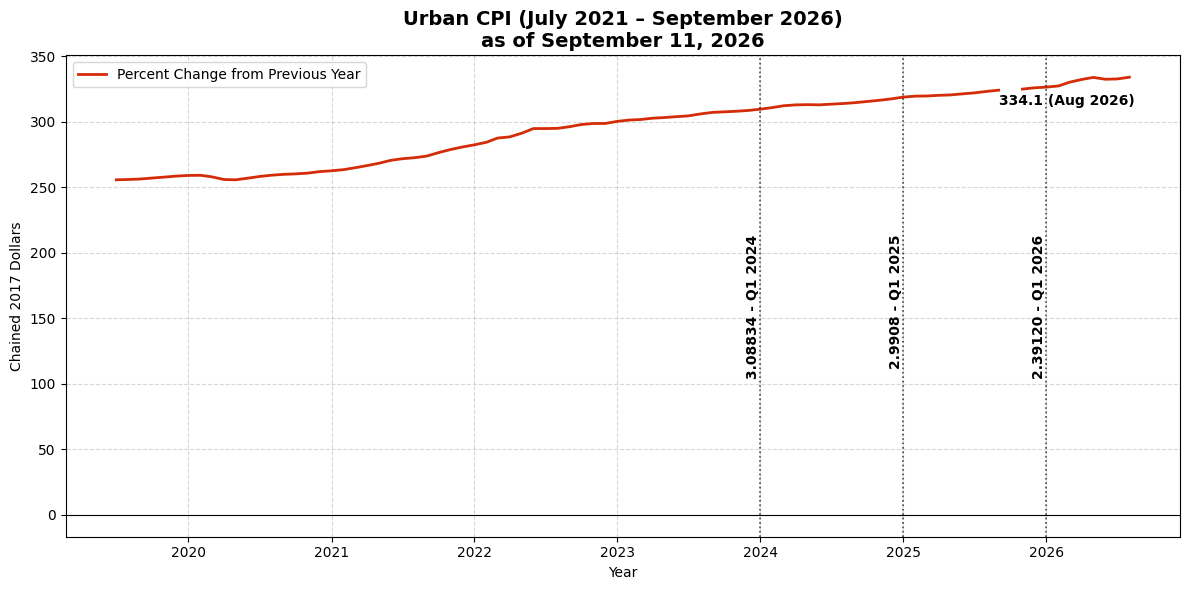

In [10]:
# source
df = web.DataReader('CPIAUCSL', 'fred', start, end)

# values
r_date = df['CPIAUCSL'].dropna().index[-1]
r_val = df['CPIAUCSL'].dropna().iloc[-1]

# timeframe
start = datetime(2021, 7, 1)
plot_start = start + relativedelta(years=1)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['CPIAUCSL'], 
         label="Percent Change from Previous Year", 
         color="#d42c06", 
         linewidth=2)

y = plt.ylim()[1]*0.5

# Event Markers
fyq_s2 = {
    '2024-01-1': '3.08834 - Q1 2024',
    '2025-01-1': '2.9908 - Q1 2025',
    '2026-01-1': '2.39120 - Q1 2026'
}

plt.title(f'Urban CPI ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Chained 2017 Dollars')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
add_event_lines(fyq_s2, df, y+45)
plt.annotate(f"{r_val:.1f} ({r_date.strftime('%b %Y')})", 
             (r_date, r_val), 
             textcoords = "offset points", 
             xytext = (-45,-20), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')


plt.show()

### Trimmed Mean PCE and PCE Inflation Rate: 5-Year Historical 

/var/folders/71/ng2k1j0j5zl7wss17qgbmsfr0000gn/T/ipykernel_58552/1856337052.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_rate['PCE Rate Excluding Food and Energy'] = df_raw['PCE Inflation Rate Excluding Food and Energy'].pct_change(12) * 100


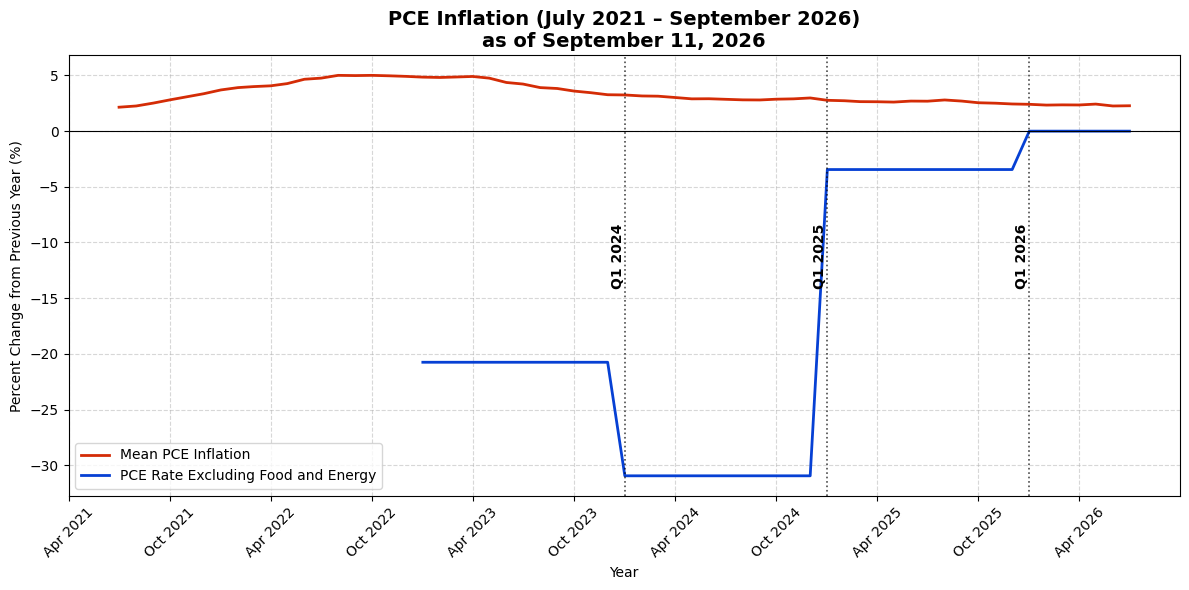

In [11]:
rate_series = {
    'PCETRIM12M159SFRBDAL': 'Trimmed Mean PCE Inflation Rate',
    'DPCCRV1A225NBEA': 'PCE Inflation Rate Excluding Food and Energy',
}

df_raw = web.DataReader(list(rate_series.keys()), 'fred', start, end)
df_raw.rename(columns=rate_series, inplace=True)

df_rate = pd.DataFrame()
df_rate['Trimmed Mean PCE Inflation Rate'] = df_raw['Trimmed Mean PCE Inflation Rate']
df_rate['PCE Rate Excluding Food and Energy'] = df_raw['PCE Inflation Rate Excluding Food and Energy'].pct_change(12) * 100

start = datetime(2021, 7, 1)
plot_start = start + relativedelta(years=1)

plt.figure(figsize=(12, 6))
plt.plot(df_rate.index, 
         df_rate['Trimmed Mean PCE Inflation Rate'], 
         label="Mean PCE Inflation", 
         color="#d42c06", 
         linewidth=2)

plt.plot(df_rate.index, df_rate['PCE Rate Excluding Food and Energy'], 
         label="PCE Rate Excluding Food and Energy", 
         color="#0640d4", 
         linewidth=2)

y = plt.ylim()[1]*0.25

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Event Markers
fyq_s3 = {
    '2024-01-1': 'Q1 2024',
    '2025-01-1': 'Q1 2025',
    '2026-01-1': 'Q1 2026'
}

plt.title(f'PCE Inflation ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percent Change from Previous Year (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
add_event_lines(fyq_s3,df,y-10)

plt.show()

# Conclusions and Observations


### Inflation – 11 September 2026

#### CPI Inflation rose **0.4%** from July to August, preserving an annualized rate of **3.4%** YoY.

Gas prices rose **3.9%** from July to August, contributing to a third of overall inflation.

The Bureeau of Labor Statisitcs (BLS) confirms shelter costs ticked up **0.3%** and food costs rose **0.1%**. 

Takeout and restaurant dining rose **0.3%** and the food index overall has risen **2.7%** in the previous year.

Notable increases weree airline fares, rising **2.7%** in August, and communications, rising **2.3&.**

---

#### **Thank you for reading. I'm still unemployed. No, I did not quit in January 2025.** 

##### And I will send you the termination letter, final pay stub, and precisely what it was I was working on on the day that happened.

#### *How am I performing?*

BLS data shows **90% of the net 807,000 jobs gained in the last 21 months, went to women.**

The math is simple, of the net average **36,000 jobs the U.S. created per month since Jan 2025**, on average...

**Only about 3,600 jobs per month were male hires.**

You're telling me 72 guys per state can "have a job?"

You're telling me the best we can do right now only two dudes a day?

Assuming we aren't planning to lose them like the **1.5 million others lost since Jan 2025?**

**Bull.**

#### This is not my jobs report. 

<u>This is me, hard checking the real world that many of us pretend we chose to live in</u>.

Prices are on a uncomfortably high rise. Wages are outpaced by a 10% rolling average. And GDP growth is much slower than just two years ago.

The U.S. is not a country that can get by on 40k jobs per month. **China, for example, creates about a million each month.**

Scaling for population, the U.S. would neeed to create about *160k wages* per month to match China's production rate.

I was working 10 years, before an undue encounter made the decision they were going to peresonally ruin my career at this point in time.

#### I'm expecting a Fed decision to raise intereest rates in the next week. 

These conditions are not sustainable and have identical indicators to societies at their times of significant reduction or even collapse.

**Abusrdly high debt, eextremme wealth disparity, depletion of what are generally obtainable resources, and diminishing returns on investment.**

I'm young enough to remember learning about the Bronze Age in elementary school a year after 9/11. I'm too old for this nonsense.

---

- ***For now, you can purchase my services on Fiverr***

    1. `Data Analytics`: Dashboards, Predictions, Evaluations, Consultation
    2. `Data Science`: Predictive Modeling, Model Training/Tuning, Data Strategy, Semantic Analysis
    3. `Software Engineering`: API Deeveelopment, Legacy Migrations, Minimum Viable Productt Development
    4. `Aritificial Intelligence`: Prompt Engineering, Agentic Workflows, Process Automation
    5. `Systetms Engineering`: Risk Assessment, Integration and Testing, Change Management, Configuration 

    ##### Hire me: http://www.fiverr.com/s/bkdd7bp

___

### Inflation – 13 August 2026

#### There is very little to elaboarte about.

Inflation fell from June to July by 0.1% from 3.5% to a negligible difference from 3.4%.

Inflation rose year-over-year from from July 2025 to July 2026 by 0.01%, from 3.3% to 3.4% year over year.

**The current St. Louis Federal reserve data refelcts an approximate 3.3% increase in headline CPI, figures are reported as 3.4% after rounding.**

---

**Thank you for reading. Now, if you are standing behind me, like in line, waiting for me to do something first, here's your chance to actually try what I do, day in and night out. I won't judge too much.**

---

### Inflation – 17 July 2026

I don’t know about you, but I feel as if we spoke about this just a couple of days ago. 

We are again, but with a little bit of good news, relatively.

Inflation for the month of June returned at 3.5% while expectations were 3.8% year-over-year. This marks a net drop of 0.4% from May. 

If you’re somebody who can do the math, you’ll say a drop of 0.4% from 4.2% doesn’t add up to 3.5%. 

For those people, I say there are margins of error that we can’t exactly count for in this day and age. 

We cannot account for is how much consumer inflation and producer inflation is going to be affected now that the U.S. has effectively dropped its own cease-fire after starting the Iran War.

#### **Abject reminder that the Okalhoma City Thunder tanked for years before winning a championship.** 

#### **Many other NBA teams employing the same strategy, have not won an NBA championship.**

***Let's look at the historical data, shall we?.***

The most recent significant job in consumer inflation prices - this is greater than 0.2% - occurred six years ago in 2020. 

I’ve got ahead and adjusted the headline and core inflation graph to include information from as early as June 2019. 

Unironically, that was also the last time inflation was at or around 2%. 

***Pandemic recovery would obviously lead to inflation. How about simultaneous wars involving world superpowers?***

With the Strait of Hormuz still closed, once more, after the third ceasefire, amidst negotiations, while America strikes Iranian military assets, while Iran retaliates Israeli instigations...

Recovery from this is going to cause global inflation. It is already causing a near global energy crisis.

Several oil producers are already planning to build new pipelines in the Middle East in order to avoid another falling out involving maritime shipping in the region. 

However building oil pipelines across thousands of miles takes years to complete. It takes even longer in an active Warzone. 

**There isn't much to speak about regarding inflation.**

Just vote accordingly. Your identification is the U.S. constituion. 

Don't vote for people who say they'll work to ease prices.

Vote for the senators, congressmen, chairmen, and administration, who put their names on the paperwork commiting to reductions.

<u>It is getting worse. Don't hold your breath.</u>

---

**Thank you for reading. The Healthcare Consumer Price Index was also updated today, give it some thought if you're interested.**

---
